In [ ]:
# Simple Archimedean spiral (numpy + scipy)
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


def archimedean_spiral_image(
    npix,
    a=0.0,
    b=4.0,
    n_arms=1,
    phase=0.0,
    n_turns=3,
    n_points=5000,
    width=1.5,
    power=1.0,
    draw_circle=True,
):
    """
    Render a simple Archimedean spiral image.
    - npix: image size (npix x npix).
    - a, b: r = a + b*theta (units = pixels if you want pixels).
    - n_arms: number of spiral arms.
    - phase: global rotation in radians.
    - n_turns: number of 2*pi turns to draw.
    - n_points: samples per arm (higher => smoother).
    - width: gaussian smoothing sigma (pixels).
    - normalize: scale max to 1.
    Returns: 2D numpy array (npix, npix).
    """
    # thetas = np.linspace(0.0, 2.0 * np.pi * n_turns, n_points, endpoint=True)
    thetas = (
        2.0 * np.pi * n_turns * np.linspace(0.1, 1, n_points, endpoint=True) ** power
    )
    xs_all = []
    ys_all = []
    for k in range(n_arms):
        th = thetas + phase - k * 2.0 * np.pi / n_arms
        r = a + b * (th - phase + k * 2.0 * np.pi / n_arms)
        x = r * np.cos(th)
        y = r * np.sin(th)
        xs_all.append(x)
        ys_all.append(y)

    xs = np.concatenate(xs_all)
    ys = np.concatenate(ys_all)

    # pixel coordinates, center the spiral in the image
    cx = (npix - 1) / 2.0
    cy = (npix - 1) / 2.0
    ix = np.round(xs + cx).astype(int)
    iy = np.round(ys + cy).astype(int)

    img = np.zeros((npix, npix), dtype=float)
    mask = (ix >= 0) & (ix < npix) & (iy >= 0) & (iy < npix)
    np.add.at(img, (iy[mask], ix[mask]), 1.0)
    img = img / img.max()

    # plt.imshow(img)
    # plt.colorbar()
    # plt.title(yo)
    # plt.show()

    if draw_circle:
        thetas_c = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)
        xc = a * np.cos(thetas_c)
        yc = a * np.sin(thetas_c)
        ix_c = np.round(xc + cx).astype(int)
        iy_c = np.round(yc + cy).astype(int)
        mask_c = (ix_c >= 0) & (ix_c < npix) & (iy_c >= 0) & (iy_c < npix)
        img[iy_c[mask_c], ix_c[mask_c]] = 1
        # np.add.at(img, (iy_c[mask_c], ix_c[mask_c]), 5e-5)

    # smooth the discrete samples into a continuous arm
    img = gaussian_filter(img, sigma=width)

    return img

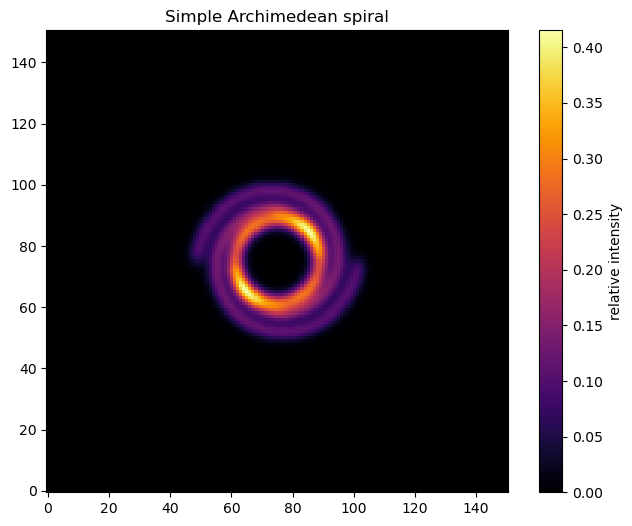

In [ ]:
import numpy.random as rd

img = archimedean_spiral_image(
    npix=151,
    a=10.0,
    b=2.0,
    n_arms=2,
    phase=0.0,
    n_turns=1,
    n_points=1_000_000,
    width=2,
    draw_circle=True,
)
plt.figure(figsize=(8, 6))
plt.imshow(img, origin="lower", cmap="inferno")
plt.colorbar(label="relative intensity")
plt.title("Simple Archimedean spiral")
plt.show()

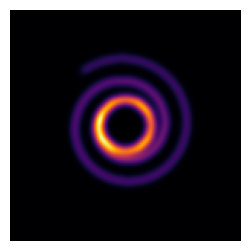

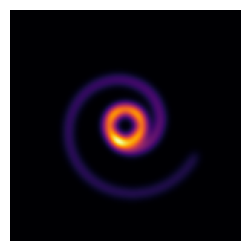

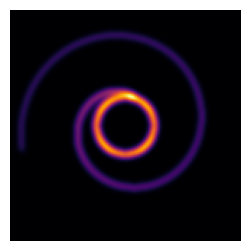

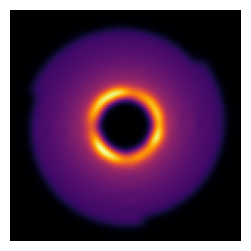

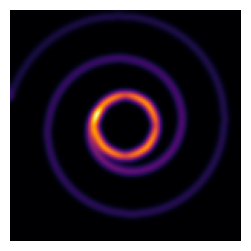

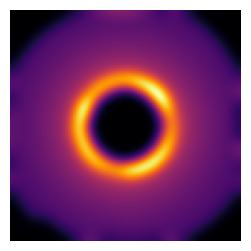

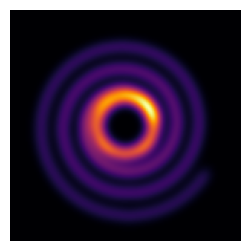

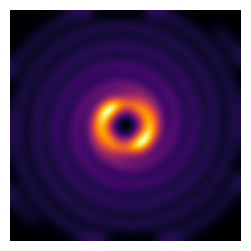

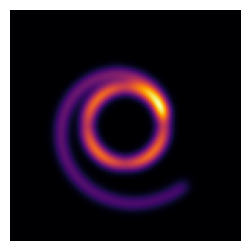

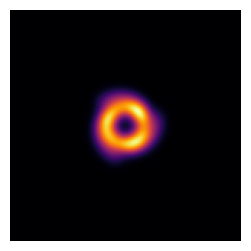

In [ ]:
# draw a few random numbers using existing variables (a, b, k, npix)
# requires numpy already imported as np in the notebook

n_samples = 10
for i in range(n_samples):
    img = archimedean_spiral_image(
        npix=151,
        a=rd.uniform(5, 30),
        b=rd.uniform(2, 6),
        n_arms=rd.randint(1, 4),
        phase=rd.uniform(0, 2 * np.pi),
        n_turns=rd.uniform(0, 3),
        n_points=1_000_000,
        width=rd.uniform(2, 5),
        draw_circle=True,
    )
    plt.figure(figsize=(4, 3))
    plt.axis("off")
    plt.imshow(img, origin="lower", cmap="inferno")
    # plt.colorbar(label="relative intensity")
    plt.show()